---
numbering: false
---

# 1.2. Loss Functions and the Constant Model

## Motivation
Suppose that you're looking for an off campus apartment for next year. Unfortunately, none of them are in your price range, so you decide to live with your parents in Detroit and commute. To see if you can save some time on the road each day, you keep track of how long it takes for you to get to school. Here's a preview of the commute times dataset. 

In [1]:
import pandas as pd

df = pd.read_csv('data/commute-times.csv')
df[['date', 'day', 'departure_hour', 'minutes']].head()

,date,day,departure_hour,minutes
0,5/15/2023,Mon,10.816667,68.0
1,5/16/2023,Tue,7.750000,94.0
2,5/22/2023,Mon,8.450000,63.0
3,5/23/2023,Tue,7.133333,100.0
4,5/30/2023,Tue,9.150000,69.0


We'll mainly focus on the ``departure_hour`` and ``minutes`` columns, which refer to time leaving the house and total time commuting respectively. Since our goal is to save time, we want to predict the value of ``minutes``, so it will be our $y$ variable. We'll use ``departure_hour`` to predict our commute time, so it will be our $x$ variable. Let's see if we can gain any insights from looking at the distribution of commute times in our dataset:

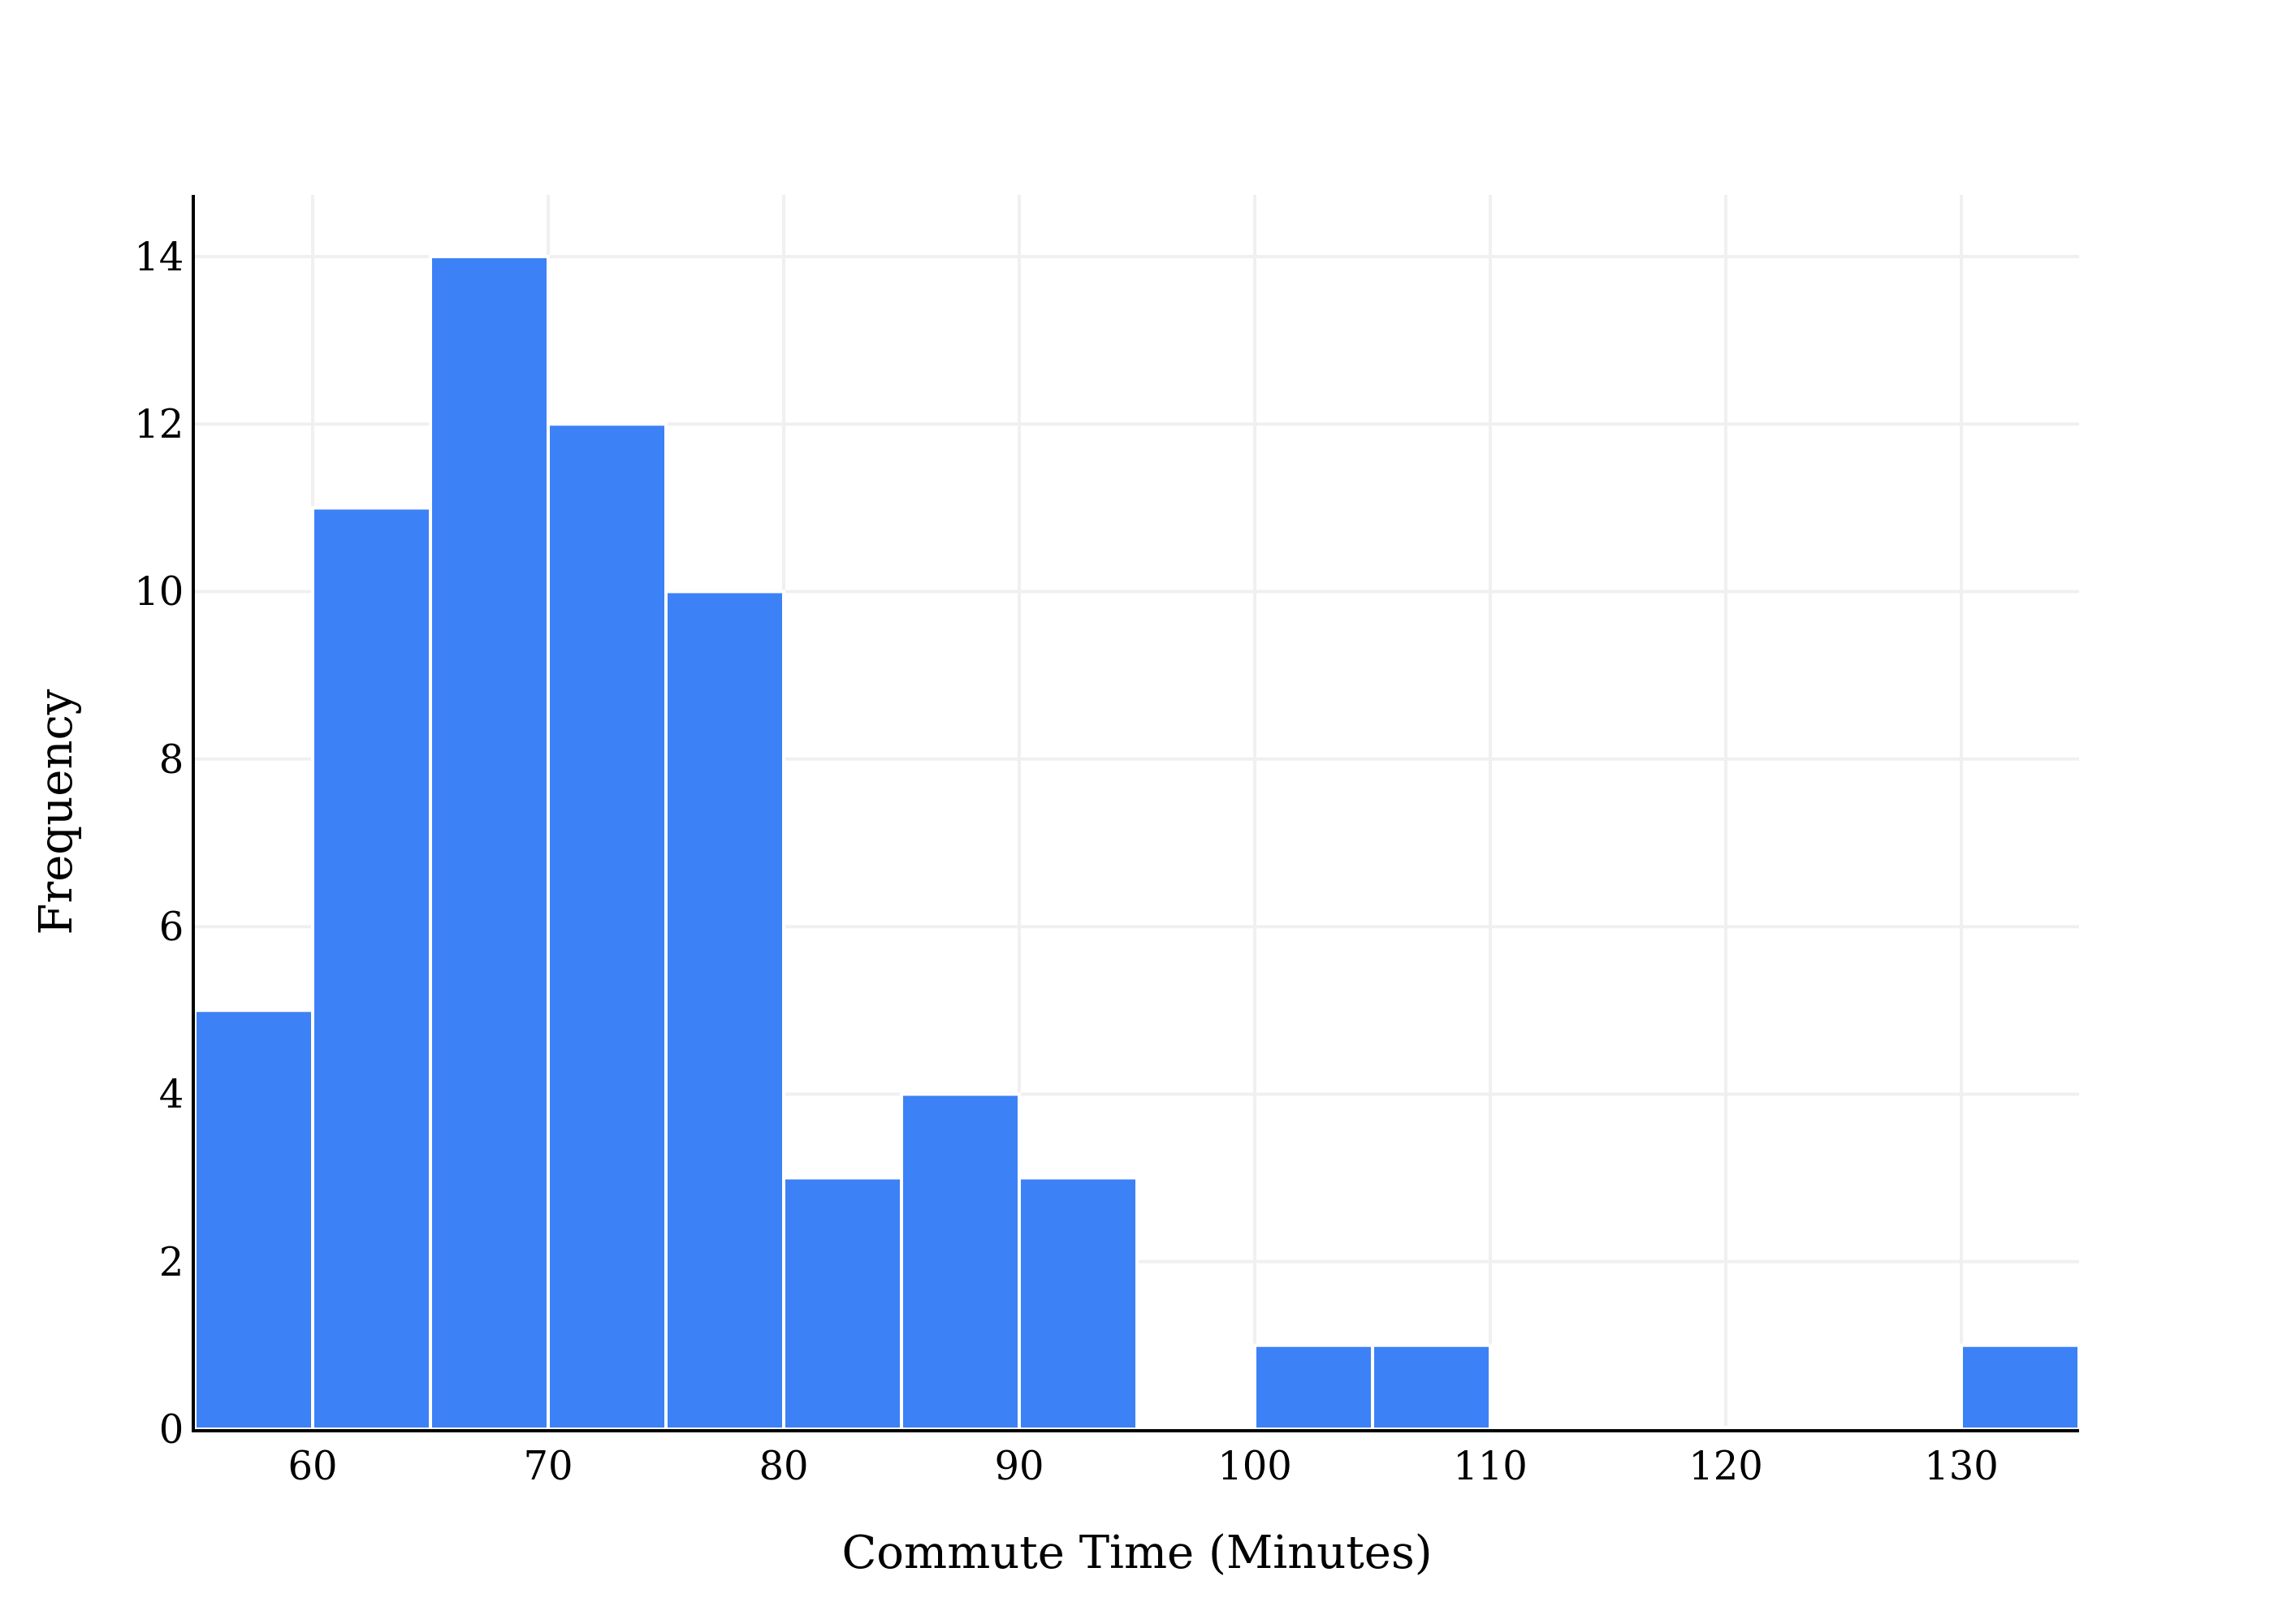

In [35]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')

fig = px.histogram(
    df, 
    x='minutes', 
    nbins=20,
)
fig.update_xaxes(
    title='Commute Time (Minutes)', 
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Frequency', 
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_traces(marker_line_color='white', marker_line_width=1, marker_color="#3D81F6")
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=4)

It seems like a typical commute is somewhere between 60 and 80 minutes, but there are outliers. Some of the commutes have taken closer to two hours, and some have been under an hour. We're using ``departure_hour`` to predict ``minutes``, so let's visualize the relationship between them with a scatter plot (recall that a scatter plot is used for quantitative data):

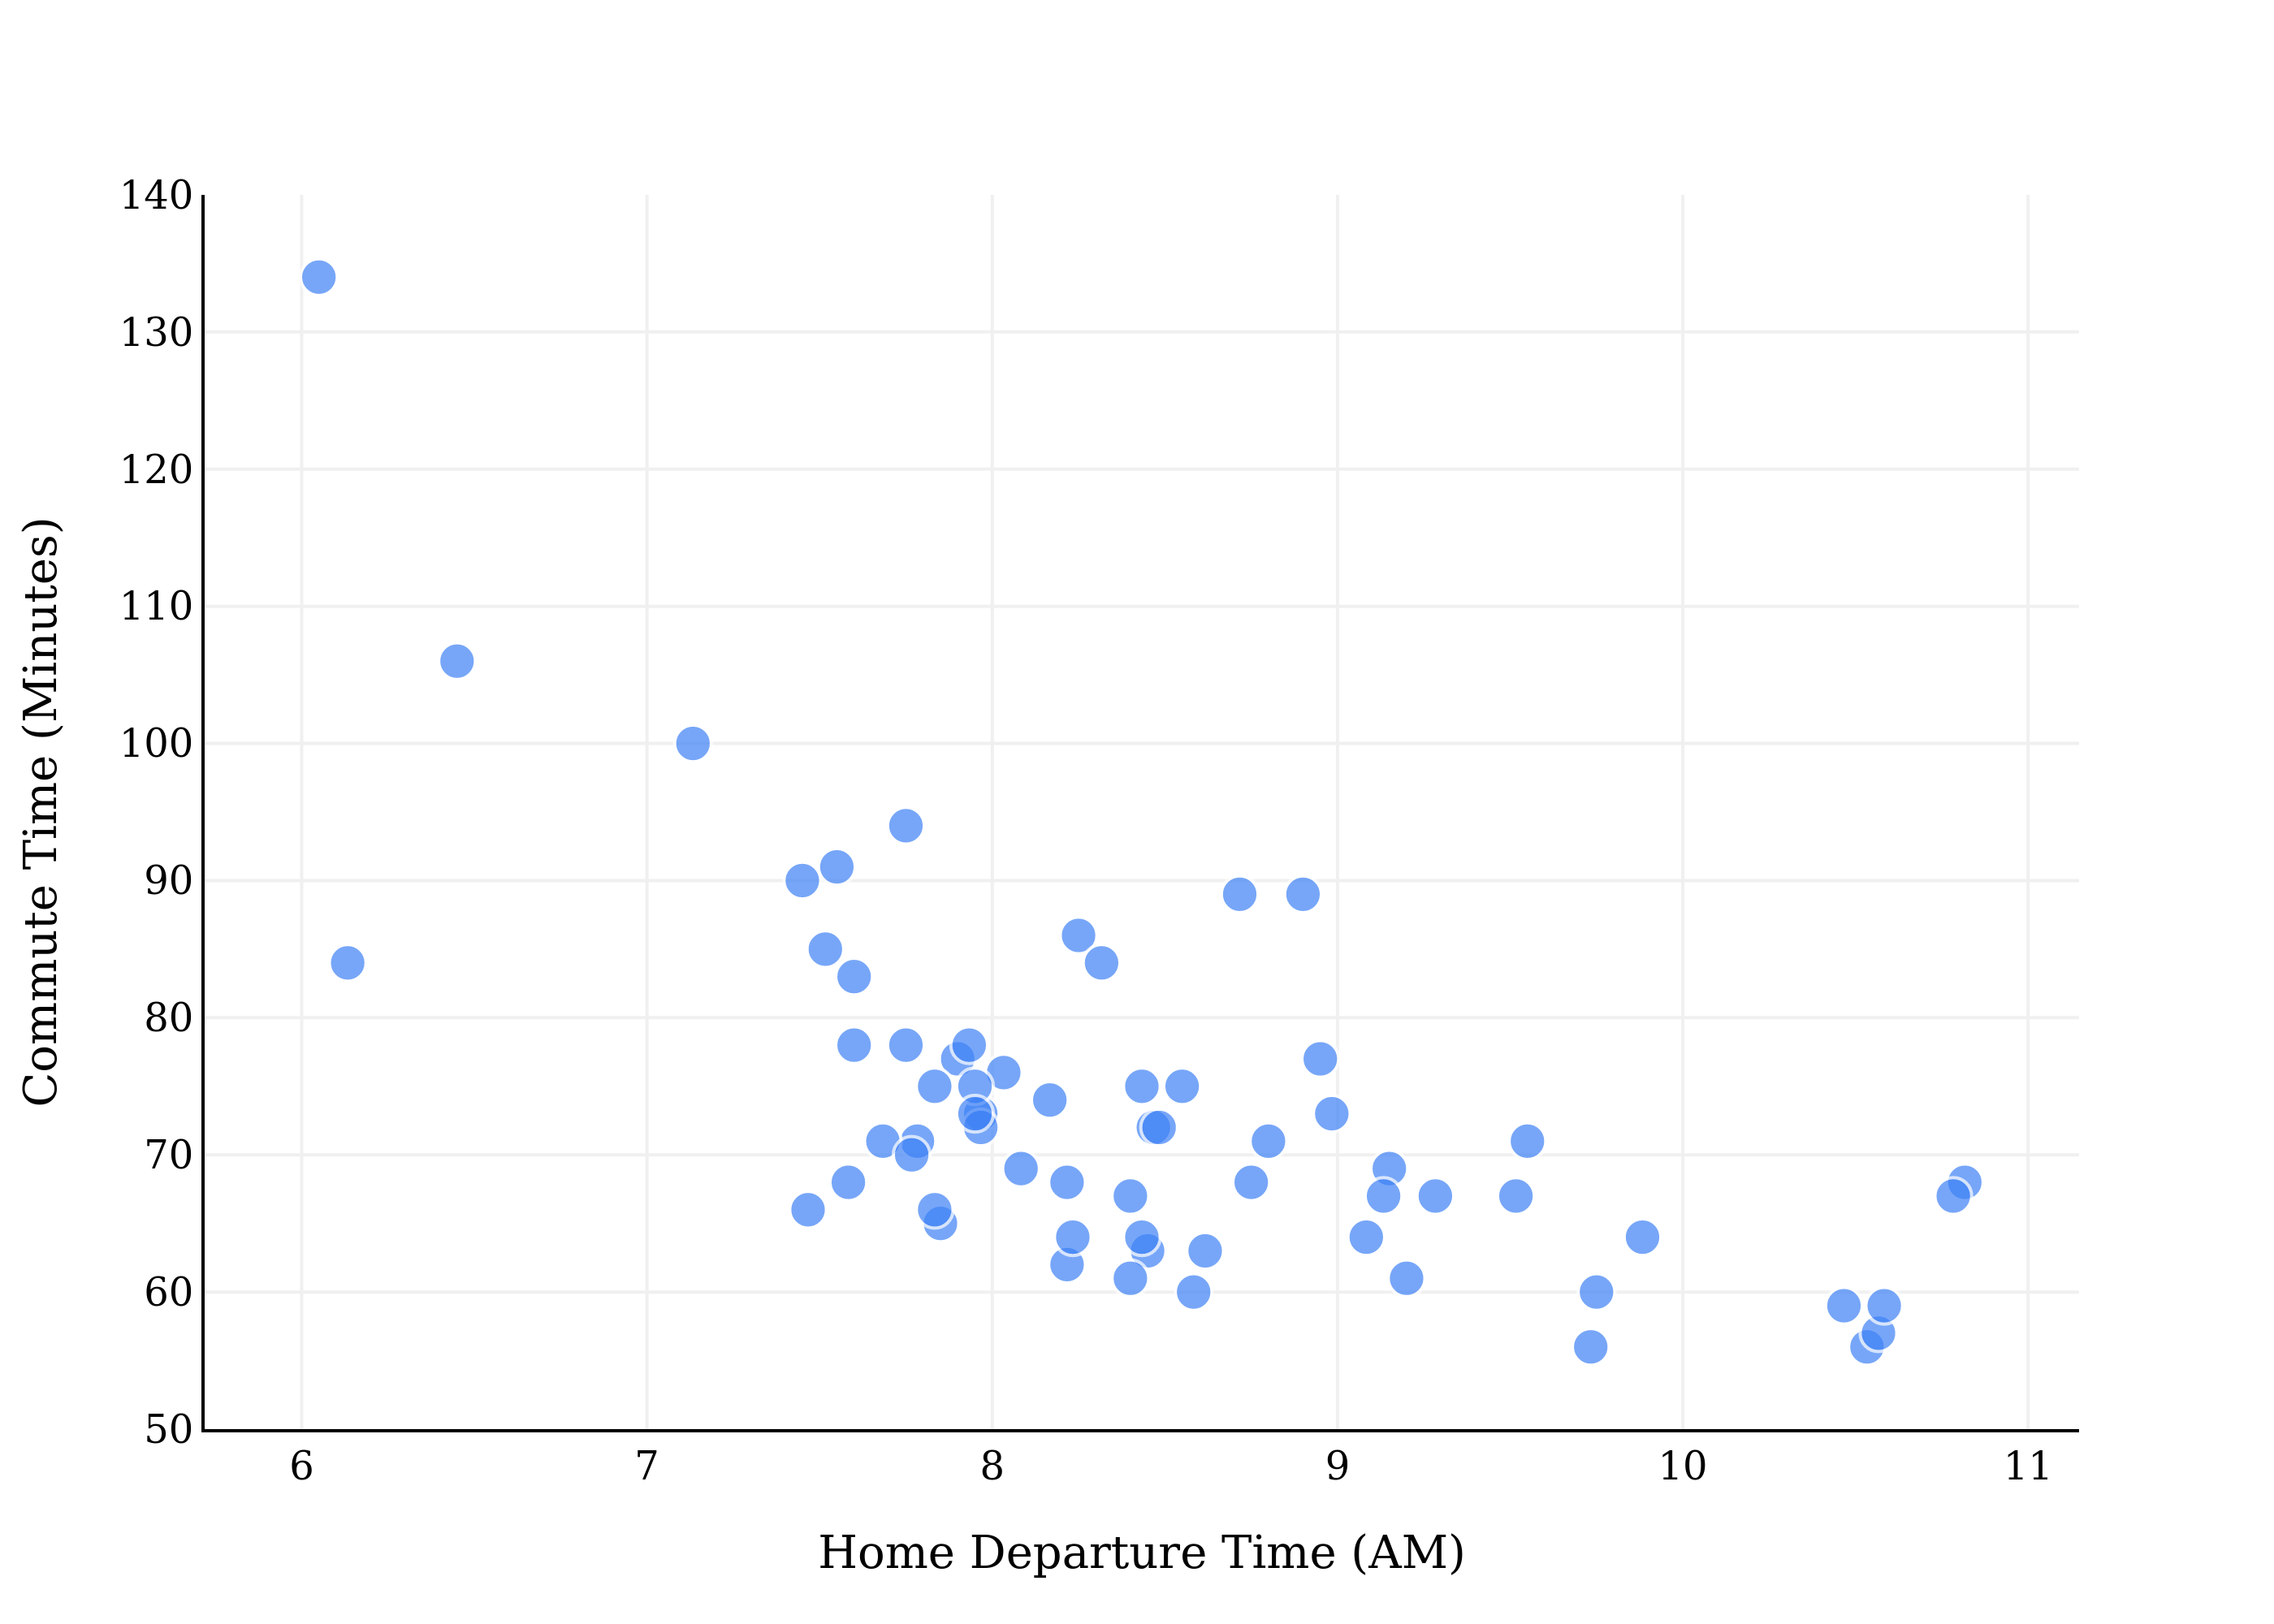

In [36]:
import pandas as pd
import numpy as np
import plotly.express as px

df = pd.read_csv('data/commute-times.csv')

fig = px.scatter(
    df,
    x='departure_hour',
    y='minutes',
    size=np.ones(len(df)) * 50,
    size_max=8
)
fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_traces(marker_color="#3D81F6")
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)
fig.show(renderer='png', scale=4)

We can observe a general downward trend: the later the departure time, the lower the commute time. Now, let's properly establish the problem to make sure we're all on the same page.

__GOAL__: Predict commute time

Problem Type: Regression - we want to predict ``minutes``, which is quantitative (or numerical) data

How to Solve: learn a pattern from the data

However, there's an important assumption we have to make for our predictions to be useful. Let's think about _why_ we're trying to predict commute time in the first place. We don't need predict the time for previous commutes, since we already know how long they took. We want to predict the time needed for _future_ commutes; ones that we don't know about yet. Therefore, we need to _assume that the future resembles our data from the past_. Another way of saying this is that we want the model to generalize well to unseen data. For example, if a new highway between Detroit and Ann Arbor gets built, the patterns previously learned will no longer be generalizable because the unseen data no longer resembles the past.  Keep the concept of generalizability in mind for later in the class, it will be much more important then.

## Models
You've probably heard the word "model" get thrown around a lot in the past few years, so let's give it a more concrete definition.

:::{note} Definition: Model
A __model__ is a set of assumptions about how data were generated.
:::

A common saying in machine learning that teaches us some important ideas about models is "all models are wrong, but some are useful":
1. Models cannot be 100% correct no matter how accurate we make them.
2. A model is useful, even if it won't always be correct. Example use cases are approximating or calculating.

A more subtle idea hidden in this statement relates to the relationship between complexity and correctness. Models can be very complex taking in several inputs and performing various mathematical operations to produce a prediction. However, there's diminishing returns because the model can never be 100% correct. You can usually get decent predictions using simple models, which can still come in handy. The complex model from earlier is a great example of this too, as even though it's more "accurate", a simple line would be more useful for predicting unseen data.

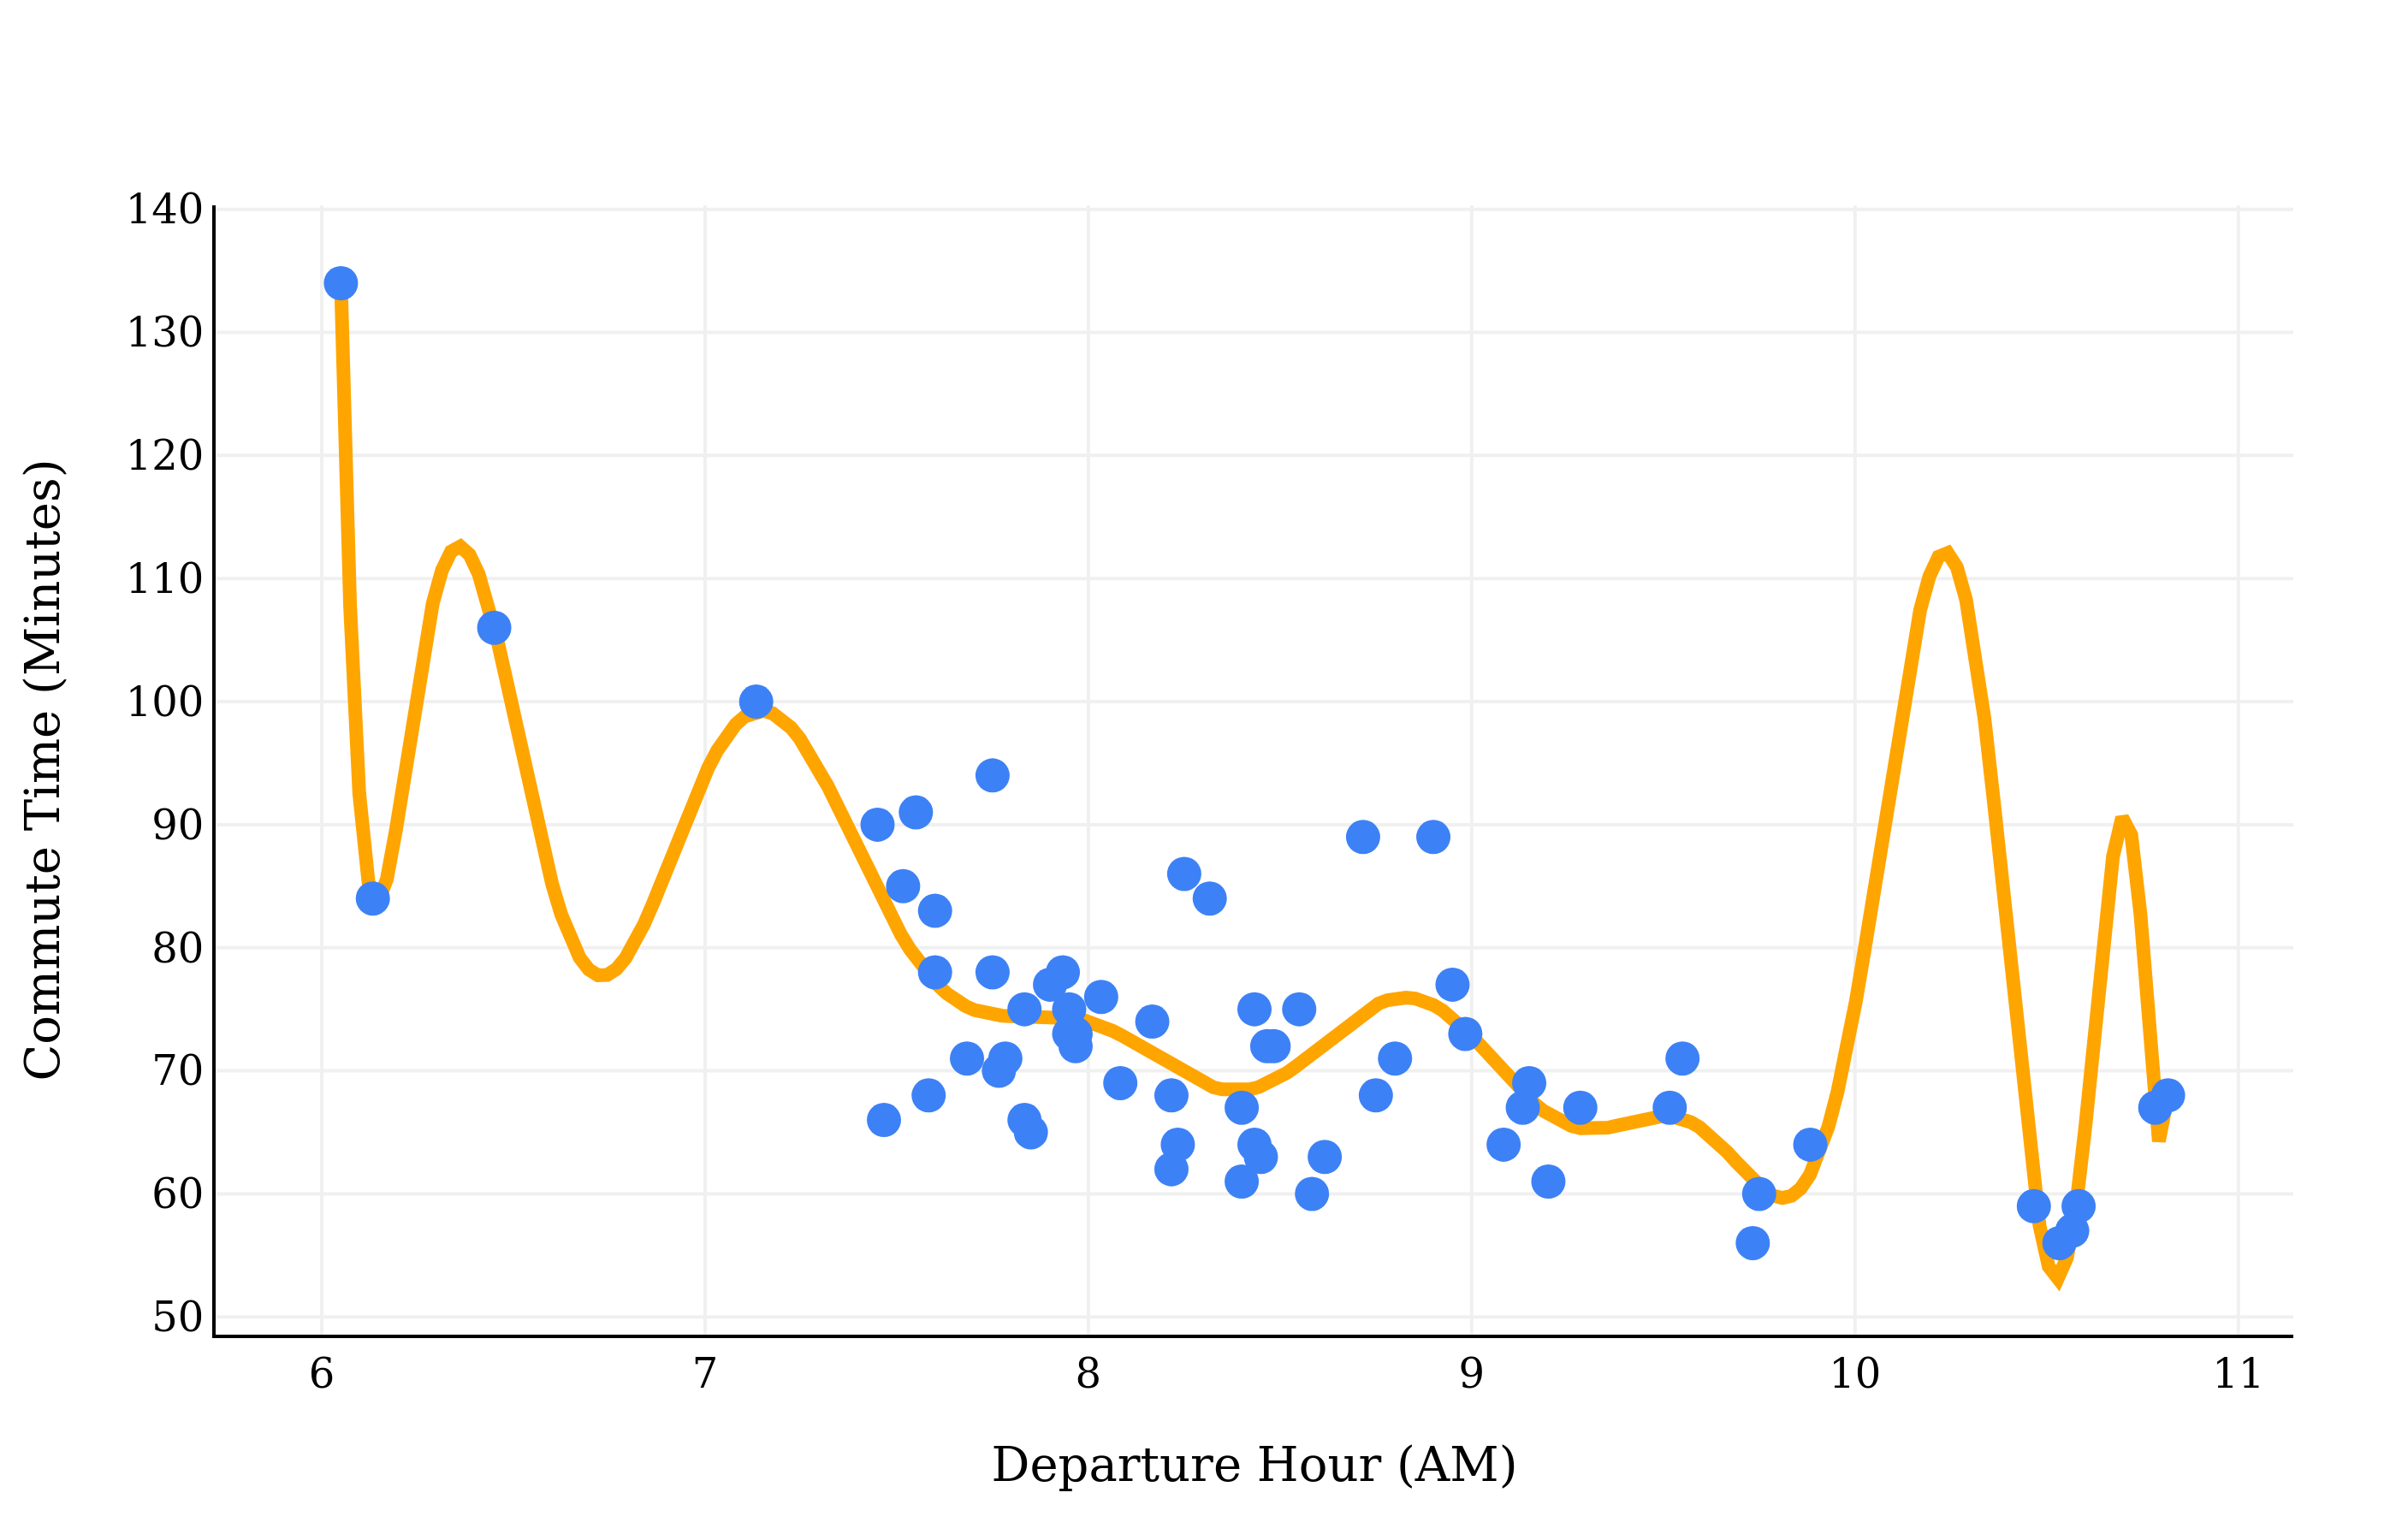

In [38]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import warnings
import numpy as np

warnings.simplefilter('ignore', np.RankWarning)

df = pd.read_csv('data/commute-times.csv')

x = df['departure_hour'].values
y = df['minutes'].values

sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

coeffs = np.polyfit(x, y, deg=50)
poly = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = poly(x_fit)

fig_overfit = go.Figure()

fig_overfit.add_trace(go.Scatter(
    x=x_fit, y=y_fit, 
    mode='lines', 
    name='Model', 
    line=dict(color='orange', width=4)
))

fig_overfit.add_trace(go.Scatter(
    x=x, y=y, 
    mode='markers', 
    name='Data', 
    marker=dict(
        color='#3D81F6', 
        size=10,
    )
))

fig_overfit.update_layout(
    showlegend=False,
    xaxis_title='Departure Hour (AM)',
    yaxis_title='Commute Time (Minutes)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=700,
    height=450,
    legend=dict(
        bgcolor='rgba(0,0,0,0)',
        bordercolor='rgba(0,0,0,0)',
        font=dict(size=14)
    ),
    margin=dict(l=60, r=30, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig_overfit.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig_overfit.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig_overfit.show(renderer='png', scale=4)

Consider the degree 50 polynomial model shown above. At first glance it looks very accurate to the commute data. In fact, it's actually _too_ accurate to the commute data, which causes the very steep spikes between the ranges that have fewer observations. If we look at the plot of the dataset and try predicting a commute time for a departure hour between 10 and 10.5 ourselves, it seems highly unlikely for it to take around 100 minutes. We call this __overfitting__ where the model is too accurate to past data and is less accurate for unseen data. In other words, it doesn't generalize well to unseen data, and isn't as useful because of it.

Returning to the scatter plot for commute times, it seems reasonable for our model to be a line of best fit. However, it would be impossible to draw a line that goes through every single point, so we have to decide which data points are more valuable for making a prediction.

## Hypothesis Functions

:::{note} Definition: Hypothesis Function and Notation
- $x$: "input", "independent variable", or "feature"
- $y$ "response", "dependent variable", or "target"

The $i$ th observation/data point is denoted $(x_i, y_i)$
Note that each $x_i$ is used to predict it's respective $y_i$

A hypothesis function $h$ takes in an $x_i$ as an input and returns a predicted $y_i$.
:::

Each hypothesis function has parameters, which define the relationship between the input and output. For example, the constant model $h(x)=w$ has only one parameter, $w$.

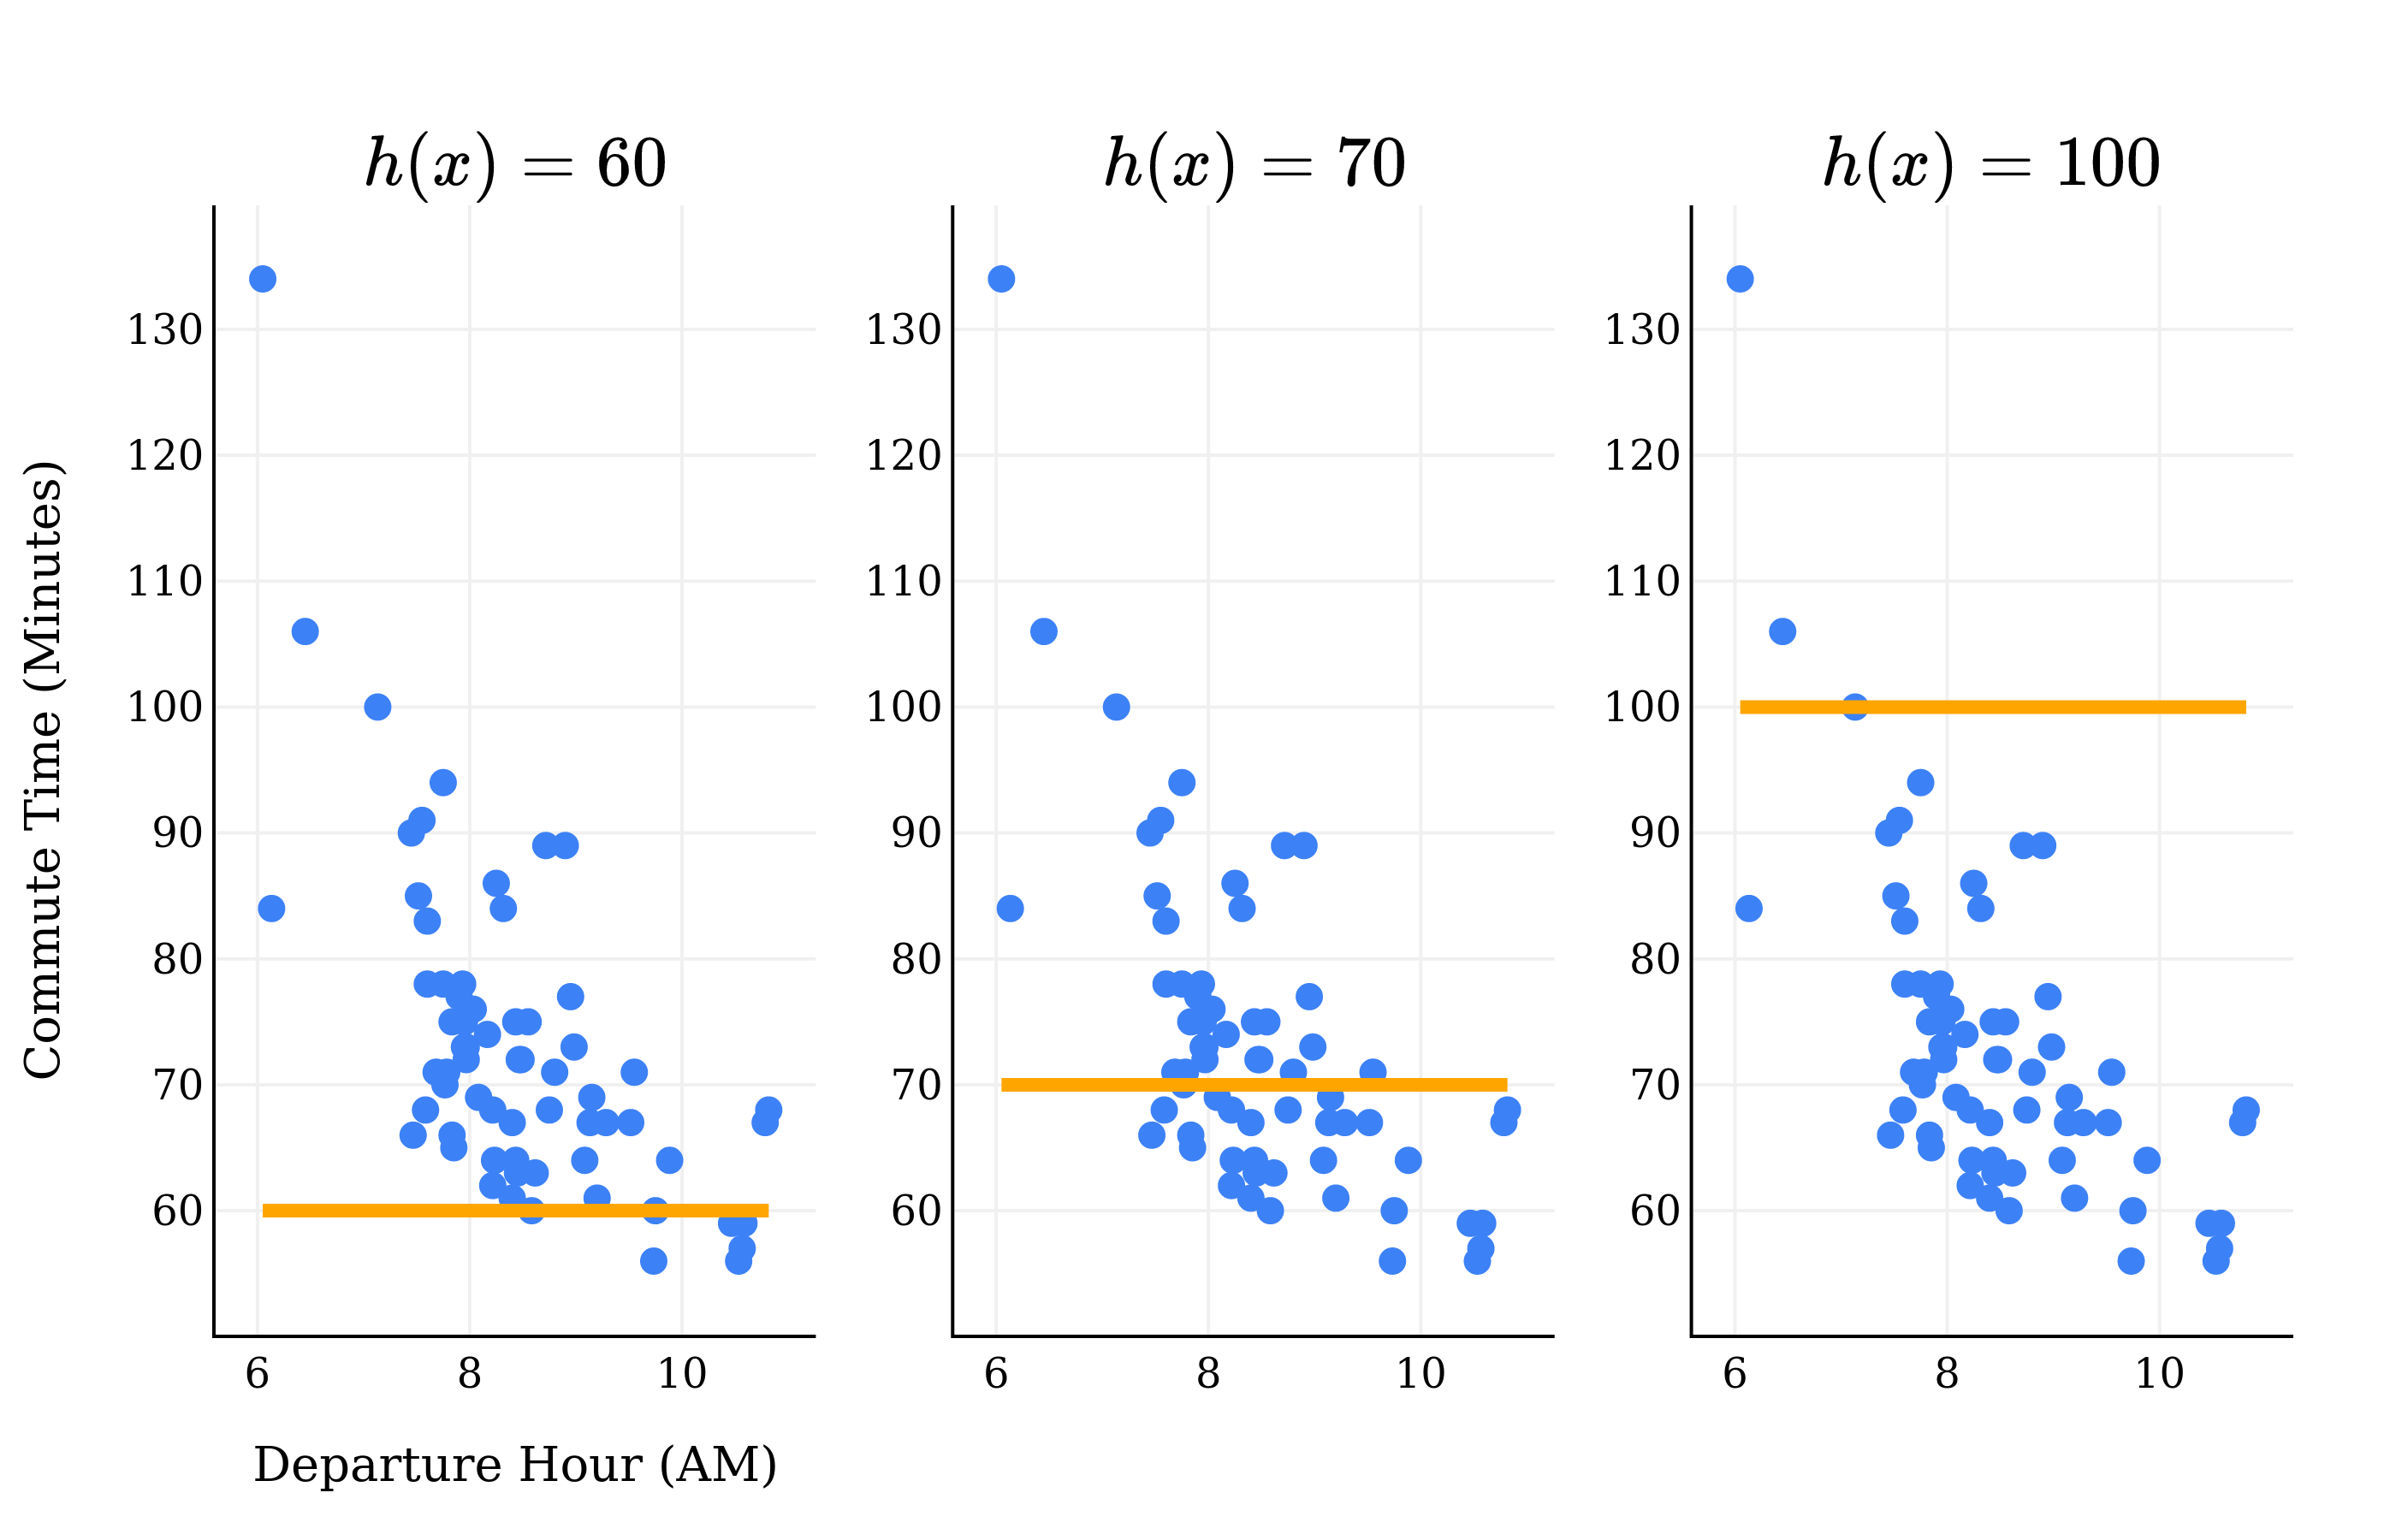

In [39]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')
constants = [60, 70, 100]


x = df['departure_hour'].values
y = df['minutes'].values

fig = go.Figure()

fig = make_subplots(rows=1, cols=3, subplot_titles=['$h(x)=60$', '$h(x)=70$', '$h(x)=100$'])

for i in range(1, 4):
    fig.add_trace(
        go.Scatter(
            x=x, 
            y=y, 
            mode='markers', 
            name='Data', 
            marker=dict(
                color='#3D81F6', 
                size=8,
            ),
            showlegend=False
        ),
        row=1, col=i
    )

    fig.add_trace(
        go.Scatter(
            x=x, 
            y=[constants[i-1]] * len(x), 
            mode='lines', 
            name=f'$h(x)={constants[i-1]}$', 
            line=dict(color='orange', width=4)
        ),
        row=1, col=i
    )

fig.update_layout(
    showlegend=False,
    xaxis_title='Departure Hour (AM)',
    yaxis_title='Commute Time (Minutes)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=700,
    height=450,
    legend=dict(
        bgcolor='rgba(0,0,0,0)',
        bordercolor='rgba(0,0,0,0)',
        font=dict(size=14)
    ),
    margin=dict(l=60, r=30, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.show(renderer='png', scale=4)

The graph of the constant model is a flat line, since it will always predict $w$ for any $x_i$. Visually, it's rather obvoius that $w=100$ would be a poor choice since it's so far from most of the data. $w=60$ and $w=70$ seem like much more reasonable predictions, but how we can quantify which one is better? Let's try with a small example first.

Suppose we have a small dataset of only 5 commute times.
$$y_1=72 \newline y_2=90 \newline y_3=61 \newline y_4=85 \newline y_5=92$$
Summary statistics such as the mean or median both seem like reasonable choices, but which one is better? It's difficult to tell without some metric to compare them with, so let's learn about one.

:::{note} Definition: Loss functions
A loss function quantifies how bad the prediction is for a single data point.
- If our prediction is __close__ to the actual value, we should have __low__ loss
- If our prediction is __far__ from the actual value, we should have __high__ loss
:::
A common starting point for a loss function is error, defined as the difference between actual and predicted values.
$$e_i={\color{3D81F6}y_i}-{\color{orange}h(x_i)}$$
where ${\color{3D81F6}y_i}$ is the <span style="color:#3D81F6">actual value</span> and ${\color{orange}h(x_i)}$ is the <span style="color:orange">predicted value</span>. Suppose the actual commute time $y_i=80$.
- If I predict 75, $e_i=80-75=5$
- If I predict 72, $e_i=80-72=8$
- If I predict 100, $e_i=80-100=-20$

A lower error is better, so 75 is a better prediction than 72. But what about 100, which has a negative error? It's difficult to interpret and compare loss with different signs, so we want to choose a loss function which can't have negative outputs, such as by squaring or taking the absolute value.

### Squared Loss
One such loss function is squared loss $L_{sq}$, which computes $({\color{3D81F6}\text{actual}}-{\color{orange}\text{predicted}})^2$
$$L_{sq}({\color{3D81F6}y_i}, {\color{orange}h(x_i)})=({\color{3D81F6}y_i}-{\color{orange}h(x_i)})^2$$

You may be thinking that the intuitive option for removing negative values is absolute loss $L_\text{abs}(y_i, h(x_1))=|x|$, so why did we choose squared loss?
- The resulting function is differentiable (more on this later)
- Theoretical relationship to the normal distribution in statistics

Choosing a loss function is an important step when designing a model, and one we'll go more in depth on later this semester. For now, let's try applying squared loss to each data point in the small example, with the median $w=85$ as or prediction.

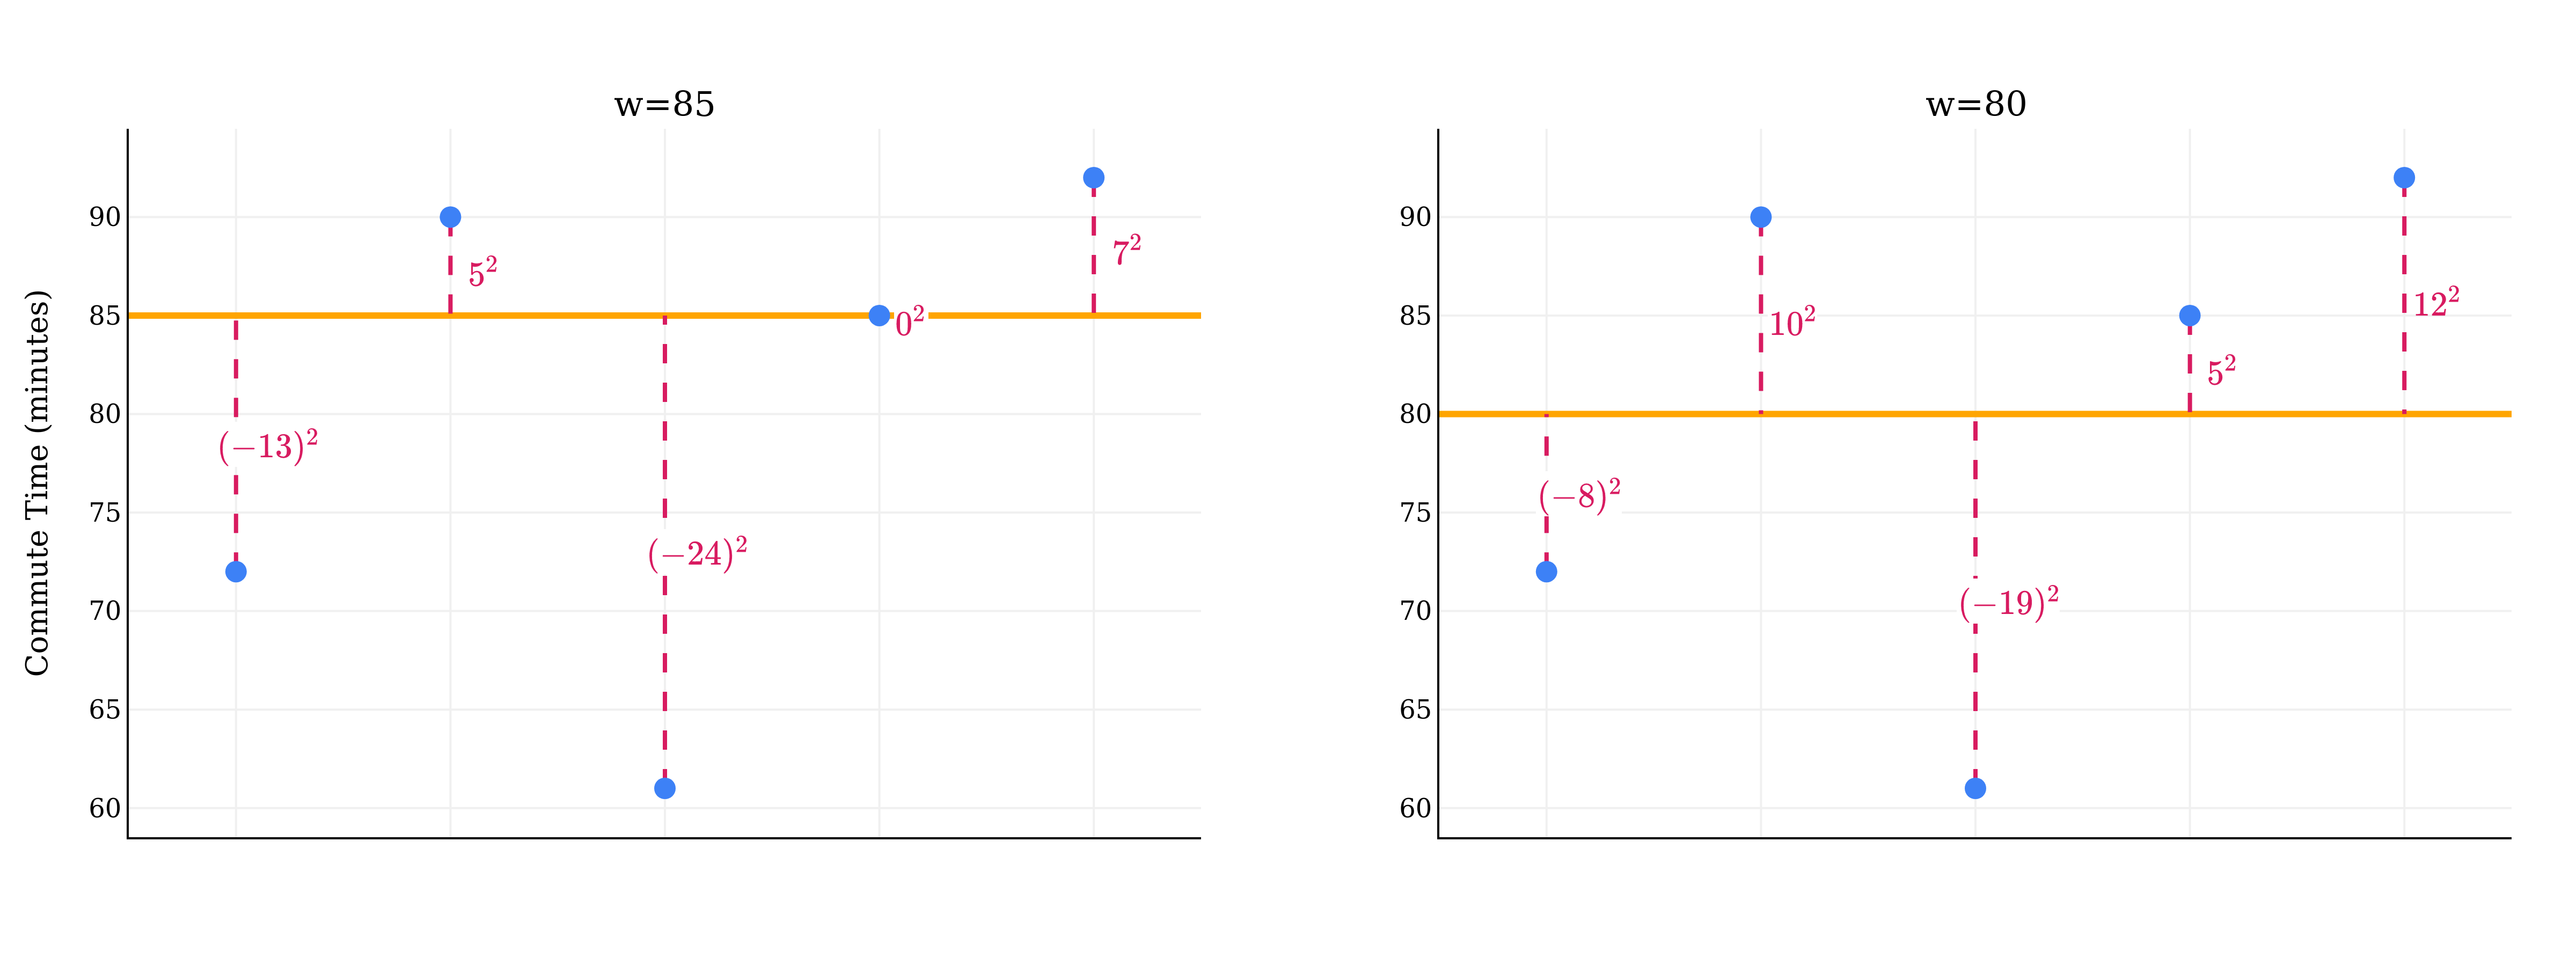

In [43]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

y = np.array([72, 90, 61, 85, 92])
preds = [85, 80]  # predictions changed to 85 and 80

# create 1 row, 2 columns
fig = make_subplots(rows=1, cols=2, subplot_titles=[f"w={p}" for p in preds])

for j, h in enumerate(preds):
    losses = y - h  # show the loss value, not squared loss

    # Horizontal prediction line
    fig.add_trace(
        go.Scatter(
            x=[0.5, 5.5],
            y=[h, h],
            mode="lines",
            line=dict(color="orange", width=3),
            name=f"$h={h}$",
            showlegend=False
        ),
        row=1, col=j+1
    )

    # Vertical dashed error lines
    for i, yi in enumerate(y):
        fig.add_trace(
            go.Scatter(
                x=[i+1, i+1],
                y=[yi, h],
                mode="lines",
                line=dict(color="#D81B60", width=2, dash="dash"),
                showlegend=False
            ),
            row=1, col=j+1
        )

    # Data points
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, 6),
            y=y,
            mode="markers",
            marker=dict(size=10, color="#3D81F6"),
            name=r"$y_i$",
            showlegend=False
        ),
        row=1, col=j+1
    )

    # Annotations for losses (show as loss, no arrow, place nearby)
    for i, (yi, loss) in enumerate(zip(y, losses)):
        fig.add_annotation(
            x=i+1 + 0.15,  # slight offset to the right
            y=(yi + h) / 2,
            text=f"${'(' + str(int(loss)) + ')' if loss < 0 else str(int(loss))}^2$",
            showarrow=False,
            bgcolor="white",
            font=dict(size=12, family="Palatino", color="#D81B60"),
            row=1, col=j+1
        )

# Shared axis styling
fig.update_xaxes(
    showticklabels=False,
    showgrid=True,
    gridwidth=1,
    gridcolor="#f0f0f0",
    showline=True,
    linecolor="black",
    linewidth=1
)
fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="#f0f0f0",
    showline=True,
    linecolor="black",
    linewidth=1
)

# Layout
fig.update_layout(
    showlegend=True,
    yaxis_title="Commute Time (minutes)",
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=1200,
    height=450,
    margin=dict(l=60, r=30, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.show(renderer="png", scale=4)


Each output of $L_\text{sq}$ tells us how good our prediction was at that specific data point, but we'd like a single number which describes the quality of our predictions across the whole dataset. That way we can compare the numbers to determine which model is better. One way to compute this is taking the average of the squared losses.

- For the median, $w = 85$:

  $$\frac{1}{5} \left( (72 - 85)^2 + (90 - 85)^2 + (61 - 85)^2 + (85 - 85)^2 + (92 - 85)^2 \right) = \boxed{163.8}$$

- For the mean, $w = 80$:

  $$\frac{1}{5} \left( (72 - 80)^2 + (90 - 80)^2 + (61 - 80)^2 + (85 - 80)^2 + (92 - 80)^2 \right) = \boxed{138.8}$$

The mean is a better prediction because it has a lower average squared loss! Another term for average squared loss is mean squared error (MSE), and it will be another important concept throught this course.

## Mean Squared Error
Let's start by generalizing mean squared error to any prediction $w$ for our small commute times dataset.
$$R_\text{sq}(w) = \frac{1}{5} \left( (72 - w)^2 + (90 - w)^2 + (61 - w)^2 + (85 - w)^2 + (92 - w)^2 \right)$$

Our result is a function that takes in any prediction $h$ and outputs the mean squared error, which is a measurement of the quality of the prediction. We can pick any $w$ as our prediction, but we want the output of $R_\text{sq}(w)$ to be as small as possible. The function is notated as $R_\text{sq}$, where the $R$ stands for risk, as in "empirical risk". Don't worry about this term for the time being, just keep in mind that $R$ is always the function for average loss.

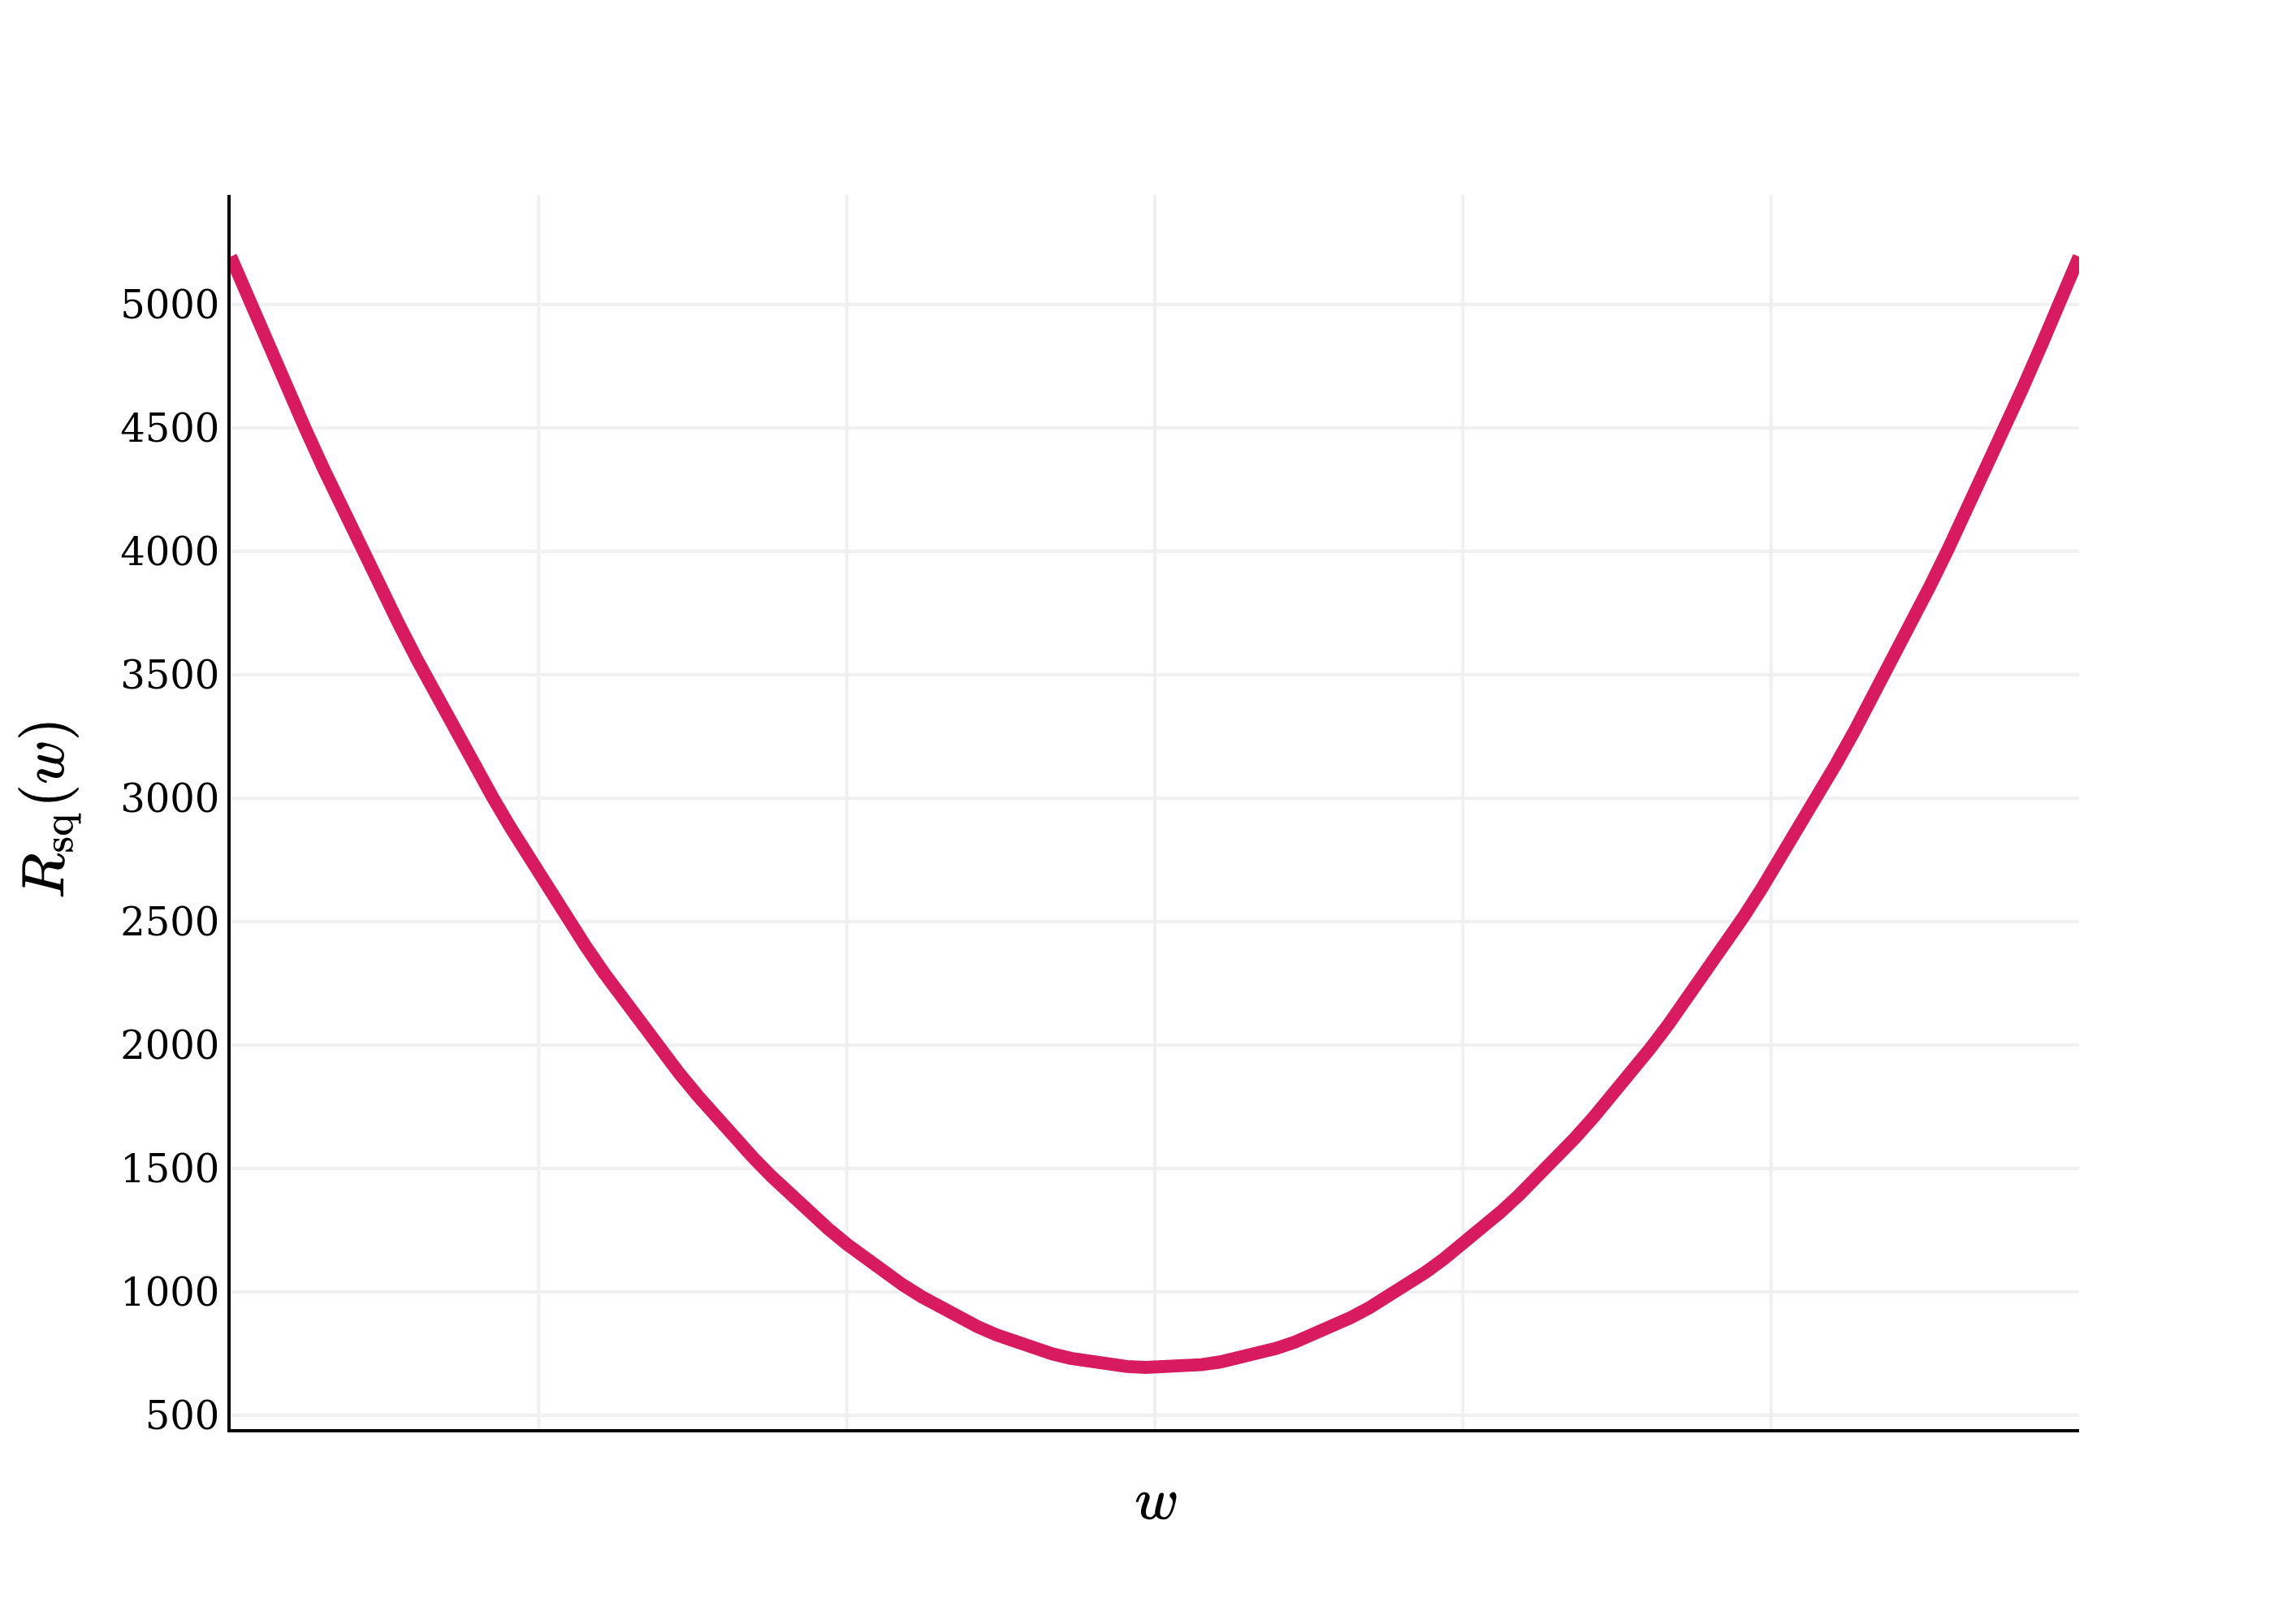

In [44]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('data/commute-times.csv')
constants = [60, 70, 100]

f = lambda h: np.mean((72-h)**2 + (90-h)**2 + (61-h)**2 + (85-h)**2 + (92-h)**2)

x = np.linspace(50, 110, 100)
y = np.array([f(h) for h in x])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x, 
        y=y, 
        mode='lines', 
        name='Data', 
        line=dict(color='#D81B60', width=4)
    )
)

fig.update_xaxes(
    showticklabels=False,
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)

fig.update_layout(
    xaxis_title=r'$w$',
    yaxis_title=r'$R_\text{sq}(w)$',
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    )
)

fig.show(renderer='png', scale=4)

We want $R_\text{sq}$ to be as small as possible, so our goal is now to find the $h$ which _minimizes_ $R_\text{sq}(w)$, called $w^*$. Before using calculus to find the minimum, let's use a more general form of mean squared error. That way we can translate this to any prediction $h$ and any set of actual values $y_1,y_2,...,y_n$. 
$$R_\text{sq}(w)=\frac{1}{n} \left((y_1- w)^2 + (y_2 - w)^2 ... + (y_n - w)^2 \right)
 = \frac{1}{n}\sum_{i=1}^n(y_i-w)^2$$

It might be confusing $\frac{\text{d}}{\text{d}w}$ see so many symbols, but here $w$ is our only variable because we know the actual values in the dataset. 

__Step 0: The derivative of $(y_i-w)^2$__<br>
In order to find the derivative of $R_\text{sq}(w)$, we'll first need to find the derivative of $(y_i-w)^2$. 
$$
\begin{aligned}
&\frac{\text{d}}{\text{d}w}(y_i-w)^2 \\
&= 2(y_i-w) \cdot \frac{\text{d}}{\text{d}w}(y_i-w) && \text{(chain rule)} \\
&= 2(y_i-w) \cdot (-1) \\
&= -2(y_i-w) 
\end{aligned}
$$

__Step 1: The derivative of $R_\text{sq}(w)$__
$$
\begin{aligned}
&\frac{\text{d}}{\text{d}w}R_\text{sq}(w) = \frac{\text{d}}{\text{d}w}\left[\frac{1}{n} \sum_{i = 1}^n (y_i - w)^2\right] \\
&= \frac{1}{n}\sum_{i = 1}^n\frac{\text{d}}{\text{d}w}(y_i - w)^2 \\
&= \frac{1}{n} \sum_{i = 1}^n -2(y_i-w) \\
&= -\frac{2}{n} \sum_{i = 1}^n(y_i-w)
\end{aligned}
$$

__Step 2: Set $\frac{\text{d}}{\text{d}w}R_\text{sq}(w)$ to 0 and solve for the minimizer $w^*$__
$$
\begin{aligned}
&-\frac{2}{n}\sum_{i = 1}^n(y_i-w)=0 \\
&\sum_{i = 1}^n y_i-\sum_{i = 1}^n w=0 \\
&\sum_{i = 1}^n y_i-nw=0 && (w_1+w_2+...+w_n=nw) \\
&\sum_{i = 1}^n y_i=nw \\
&w^*=\frac{1}{n}\sum_{i = 1}^ny_i=\text{Mean}(y_1,...,y_n) \\
\end{aligned}
$$

__Step 3: Second Derivative Test__
$$
\begin{aligned}
&\frac{\text{d}^2}{\text{d}^2w}R_\text{sq}(w) \\
&=\frac{\text{d}}{\text{d}w}\left[-\frac{2}{n} \sum_{i = 1}^n(y_i-w)\right]\\
&=-\frac{2}{n} \sum_{i = 1}^n \frac{\text{d}}{\text{d}w}(y_i-w)\\
&=-\frac{2}{n} \sum_{i = 1}^n -1 \\
&= -\frac{2}{n} \cdot -n\\
&= 2
\end{aligned}
$$

Since the second derivative is positive, we can conclude that the mean minimizes mean squared error when using the constant model. Another name for the $w^*$ we found is an __optimal model parameter__.

:::{note} Definition: The Modeling Recipe
Now that we've been through an example of what a model is, here's a general framework finding optimal model parameters for making predictions.
1. Choose a model
2. Choose a loss function
3. Minimize average loss to find optimal model parameters
:::

In our example, we used the constant model, squared loss, and computed $h^*$ as our one optimal model parameter. Models can have many more parameters, each of which has an optimal value for minimizing average loss. Something worth noting here is that average loss depends on which loss function was chosen, so the optimal parameters can change for different loss functions.

## Conclusion
Over the course of this lesson, we've encountered a prediction problem and a model to use - the constant model. Applying what we've learned about the constant model to our commute times problem, we get the following line:

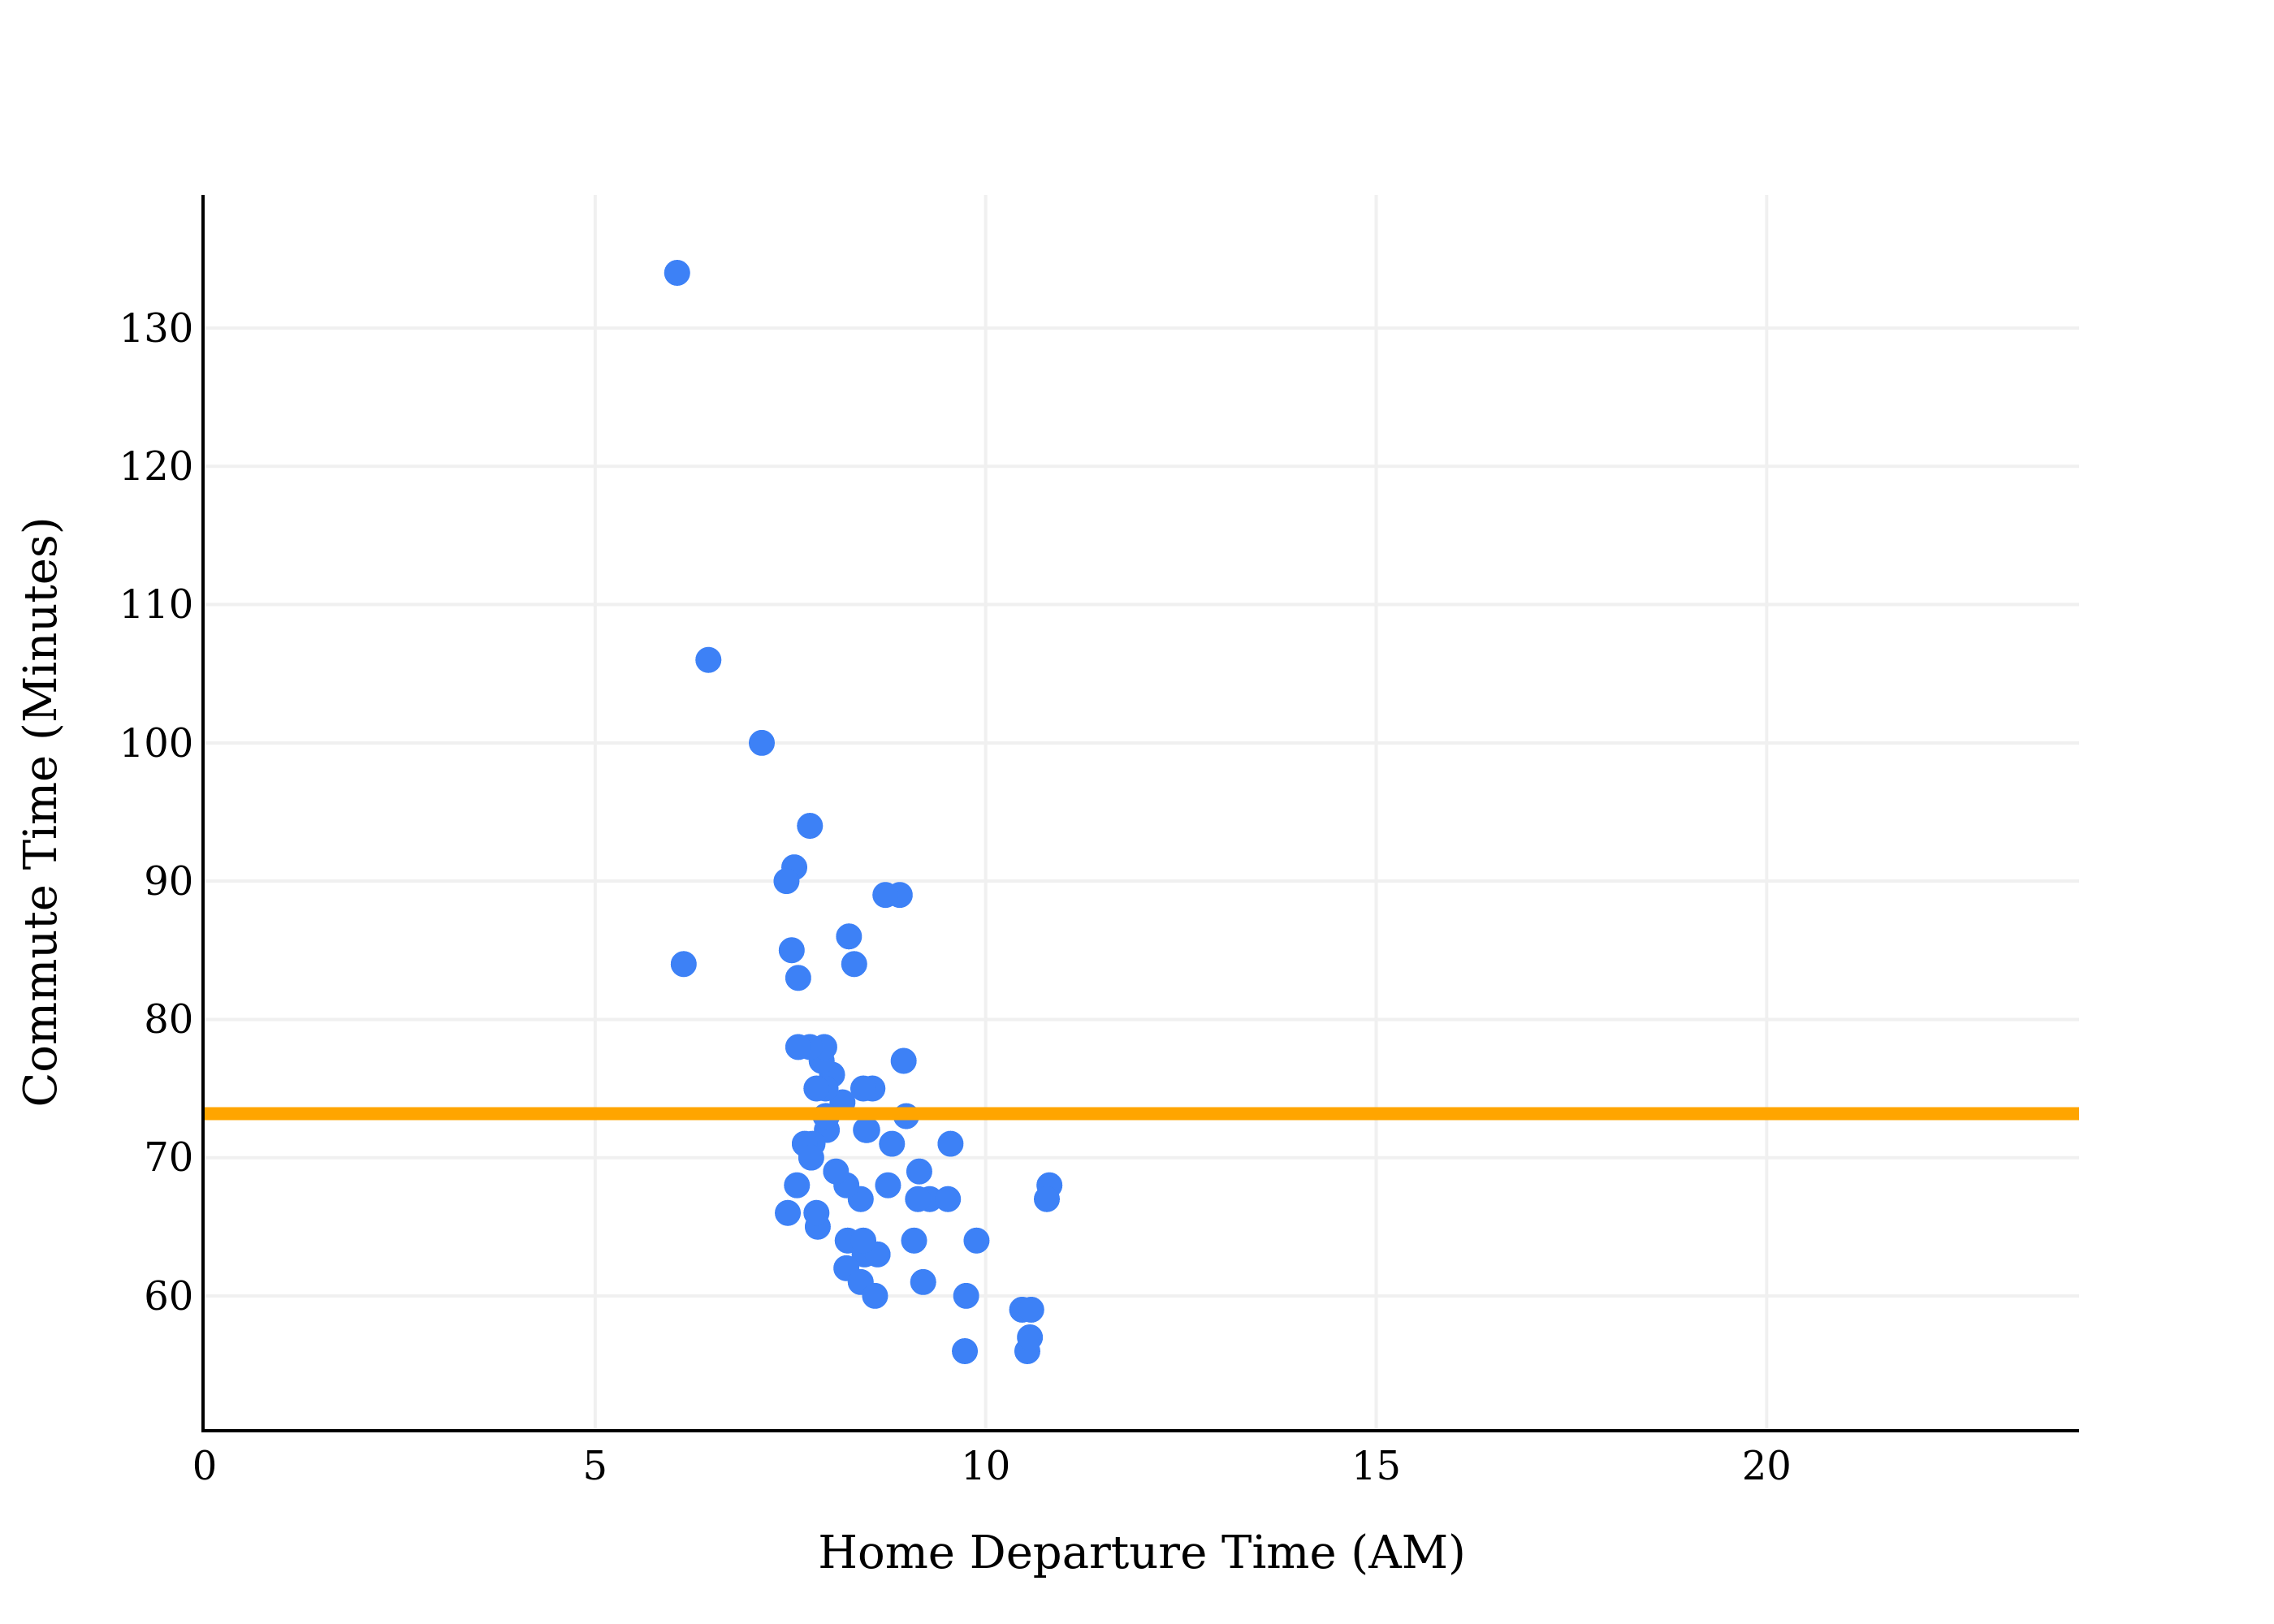

In [9]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

df = pd.read_csv('data/commute-times.csv')
y_mean = df['minutes'].mean()

fig = go.Figure()

# Scatter points
fig.add_trace(go.Scatter(
    x=df['departure_hour'],
    y=df['minutes'],
    mode='markers',
    marker=dict(size=8, color="#3D81F6"),
    name='Commute Time'
))

# Mean line
fig.add_trace(go.Scatter(
    x=[0, 24],
    y=[y_mean, y_mean],
    mode='lines',
    line=dict(color='orange', width=4),
    name='Mean'
))

# Axes and layout
fig.update_xaxes(
    title='Home Departure Time (AM)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_yaxes(
    title='Commute Time (Minutes)',
    gridcolor='#f0f0f0',
    showline=True,
    linecolor="black",
    linewidth=1,
)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    width=700,
    font=dict(family="Palatino Linotype, Palatino, serif", color="black"),
    showlegend=False,
)

fig.show(renderer='png', scale=4)


Our constant line $H^*$ is set at the mean of `minutes`, minimizing the mean squared error. While a commute taking about an hour is a reasonable estimate, if we want to make more accurate predictions we should consider factoring departure time into the model as well. The constant model is unable to account for the negative linear relationship between `departure_hour` and `minutes`, which is visible at a glance. We'll learn about how to factor that into a model in hopes of more accurate predictions soon! As a general rule of thumb, the constant model will rarely give you the best predictions, but it can be a good way to sanity check more complex models. 